# Постановка задачи


**Цель работы:** изучение основных способов визуализации табличных данных с помощью модулей `seaborn`, `plotly`, `altair`, `bokeh`.

**Краткое описание:** в лабораторной работе представлено 10 заданий на построение графиков разных видов. В каждом задании указано, каким видом графика стоит воспользоваться для визуализации данных. По каждому заданию необходимо построить график дважды: первый раз с помощью модуля `seaborn` (альтернативно можно `matplotlib` со стилями из `seaborn`), второй – с помощью `plotly`, `altair` или `bokeh` на выбор студента. Необязательно каждый раз для второго графика выбирать одну и ту же библиотеку, т.к. не все библиотеки располагают одинаковым набором графиков.

# Данные


По [ссылке](https://drive.google.com/drive/folders/1e0E4vQzaE9LBZgfzz0AzsyAXgtH0eMaP?usp=share_link) расположена таблица с информацией о песнях, исполненных на Евровидении с 2009 по 2023 год. Все задания лабораторной работы необходимо выполнять по этим данным. Данные в полном объеме можно найти [по ссылке](https://www.kaggle.com/datasets/diamondsnake/eurovision-song-contest-data).

##### **Формат данных**

```
year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110,36,64,23,10 dB,58,0,10,3,5
2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103,78,70,82,6 dB,2,0,18,4,
...
```
##### **Описание полей**

- ```year``` – год;
- ```country``` – страна участника;
- ```artist_name``` – исполнитель;
- ```song_name``` – название песни;
- ```language``` – язык, на котором исполняется песня;
- ```style```	– жанр;
- ```gender``` – пол участника;
- ```main_singers``` – количество вокалистов;
- ```key```	– регистр (высота тона);
- ```BPM``` – скорость композиции в целом (количество четвертых нот в минуту);
- ```energy``` – энергичность композиции;
- ```danceability``` – танцевальность (насколько трек подходит для танцев);
- ```happiness``` – жизнерадостность;
- ```loudness``` – громкость;
- ```acousticness``` – акустичность;
- ```instrumentalness``` – инструментальность;
- ```liveness``` – живость;
- ```speechiness``` – насколько много текста;
- ```final_place``` – место в финале.

# Практические задания

>По каждому заданию должен быть сделан вывод. Также нужно обязательно добавлять подпись графика и осей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.figure_factory import create_distplot
import altair as alt
import seaborn as sns
import bokeh as bk
import bokeh.plotting as bkp
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import warnings
warnings.filterwarnings("ignore")

sns.set_palette("flare")
sns.set()

Mounted at /content/drive


In [23]:
!pip install squarify

## Задание 1

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/song_data.csv")
df.sample(5)

,year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
239,2017,Germany,Levina,Perfect Life,English,Pop,Female,1,Eb Major,124,70,81,52,6 dB,38,0,13,5,25.0
82,2021,North Macedonia,Vasil,Here I Stand,English,Ballad,Male,1,G Major,138,20,32,13,11 dB,51,0,32,4,NaN
325,2014,Estonia,Tanja,Amazing,English,Dance,Female,1,F Minor,128,63,64,14,7 dB,1,43,12,4,NaN
453,2011,Croatia,Daria,Celebrate,English,Dance,Female,1,Fs Major,128,87,77,38,7 dB,0,84,8,4,NaN
528,2009,Armenia,Inga and Anush,Jan Jan,"English, Armenian",Traditional,Female,2,E Minor,115,86,78,76,4 dB,36,0,35,8,10.0


Проведите предобработку числовых значений в датасете:
1. В столбцах `BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` замените отсутствующие значения и прочерки на 0.
2. В столбце `loudness` оставьте только число без единиц измерения.
3. Во всех перечисленных в пунктах 1 и 2 столбцах преобразуйте значения в тип данных `float`.

In [3]:
cols = ["BPM", "energy", "danceability", "happiness", "acousticness", "instrumentalness", "liveness", "speechiness", "loudness"]
df["loudness"] = df["loudness"].str.extract("^(\d+) dB$")
df[cols] = df[cols].fillna(0)
df[cols] = df[cols].replace("-", "0")
df[cols] = df[cols].astype(float)
del cols[-1]

## Задание 2

Покажите, какие характеристики музыки (`BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) коррелируют между собой. Для визуализации используйте диаграмму `heatmap`.

Text(0.5, 1.0, 'Correlation matrix for features')

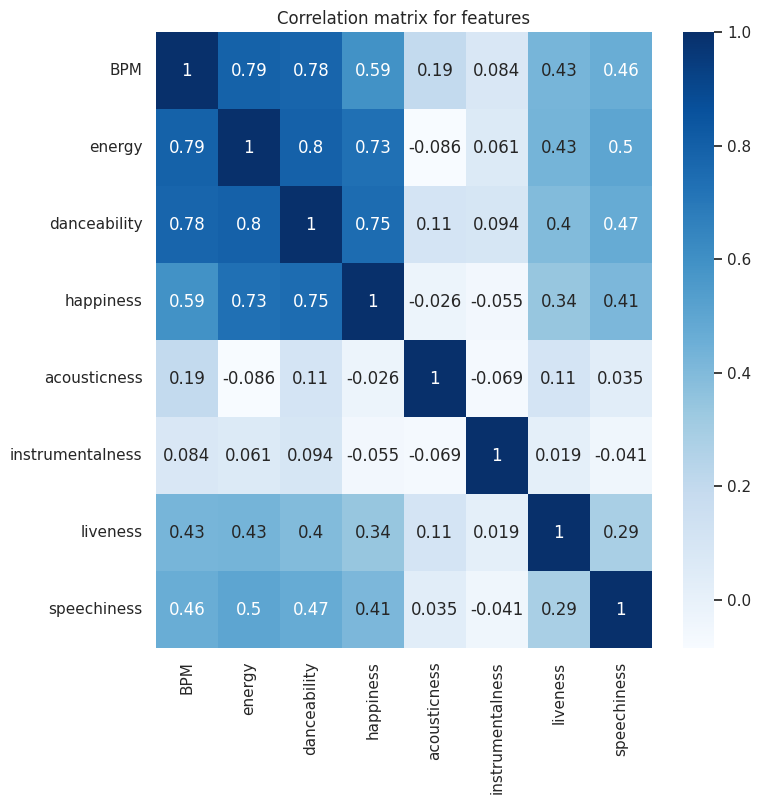

In [4]:
plt.figure(figsize=(8, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation matrix for features")

In [5]:
fig = px.imshow(df[cols].corr().iloc[::-1], color_continuous_scale='Blues', text_auto=True, title="Correlation matrix for features")
fig.update_layout(title={'x': 0.5})

Видно, что несколько признаков образуют группу, где каждые два признака хорошо коррелируют между собой - это признаки ```BPM```, ```energy```, ```danceability``` и ```happiness```. Логично, что чем выше скорость композиции, тем она более энергичная и танцевальная (равно как и то, что более танцевальная музыка является и более энергичной). Жизнерадостность композиции слабее коррелирует с BPM, однако с энергичностью и танцевальностью корреляция сильнее (под более жизнерадостную музыку и танцевать сильнее хочется)

Признаки акустичность ```acousticness``` и инструментальность ```instrumentalness``` слабо кореллируют с другими числовыми признаками.

Корелляция между живостью ```liveness``` и количеством слов ```speechiness``` и признаками из группы есть, но слабее, чем внутри группы. Если относительно количества слов и правда сложно делать выводы, связан ли этот признак с чем-либо еще, то "живость" композиции как будто очень похожа на энергичность (в силу лексического значения слов). Стоит задуматься, что именно имеется в виду под живостью и как это признак оценивается.  

## Задание 3

Покажите на диаграмме разброса взаимосвязь между жизнерадостностью (`happiness`) и энергичностью (`energy`) композиции. Добавьте на диаграмму вспомогательные элементы (отметку средних значений, выбросов) для упрощения интерпретации визуализации.



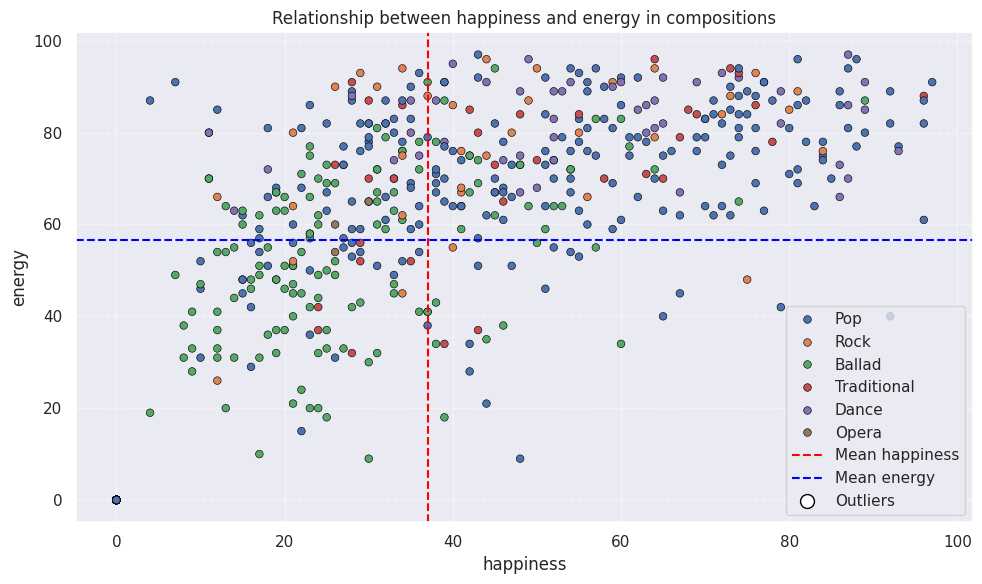

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='happiness', y='energy', hue="style", s=30, edgecolor='black')

mean_happiness = df['happiness'].mean()
mean_energy = df['energy'].mean()
plt.axvline(mean_happiness, color='red', linestyle='--', label='Mean happiness')
plt.axhline(mean_energy, color='blue', linestyle='--', label='Mean energy')

Q1_h = df['happiness'].quantile(0.25)
Q3_h = df['happiness'].quantile(0.75)
IQR_h = Q3_h - Q1_h
Q1_e = df['energy'].quantile(0.25)
Q3_e = df['energy'].quantile(0.75)
IQR_e = Q3_e - Q1_e

outlier_condition = (
    (df['happiness'] < Q1_h - 1.5 * IQR_h) | (df['happiness'] > Q3_h + 1.5 * IQR_h) |
    (df['energy'] < Q1_e - 1.5 * IQR_e) | (df['energy'] > Q3_e + 1.5 * IQR_e)
)
outliers = df[outlier_condition]
plt.scatter(outliers['happiness'], outliers['energy'], color='white', edgecolor='black', s=100, label='Outliers')

plt.title('Relationship between happiness and energy in compositions')
plt.xlabel('happiness')
plt.ylabel('energy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
fig = px.scatter(
    df,
    x='happiness',
    y='energy',
    color='style',
    opacity=0.7,
    title='Relationship between happiness and energy in compositions',
)

mean_happiness = df['happiness'].mean()
mean_energy = df['energy'].mean()
fig.add_shape(type="line", x0=mean_happiness, x1=mean_happiness, y0=0, y1=1,
              line=dict(color="red", dash="dash"), xref='x', yref='paper')
fig.add_shape(type="line", y0=mean_energy, y1=mean_energy, x0=0, x1=1,
              line=dict(color="blue", dash="dash"), yref='y', xref='paper')

Q1_h = df['happiness'].quantile(0.25)
Q3_h = df['happiness'].quantile(0.75)
IQR_h = Q3_h - Q1_h
Q1_e = df['energy'].quantile(0.25)
Q3_e = df['energy'].quantile(0.75)
IQR_e = Q3_e - Q1_e

outlier_condition = (
    (df['happiness'] < Q1_h - 1.5 * IQR_h) | (df['happiness'] > Q3_h + 1.5 * IQR_h) |
    (df['energy'] < Q1_e - 1.5 * IQR_e) | (df['energy'] > Q3_e + 1.5 * IQR_e)
)
outliers = df[outlier_condition]

fig.add_trace(go.Scatter(
    x=outliers['happiness'],
    y=outliers['energy'],
    mode='markers',
    marker=dict(color='white', size=12, line=dict(color='black', width=1)),
    name='Outliers',
    showlegend=True
))

fig.update_layout(
    xaxis=dict(gridcolor='lightgray'),
    yaxis=dict(gridcolor='lightgray'),
    legend=dict(title='Style'),
    plot_bgcolor='white',
    title_x=0.5
)

fig.show()


Видно, что жизнерадостных неэнергичных песен почти нет. Баллады сосредоточены в 3 кваддранте, то есть это нежизнеродостные неэнергичные песни. А танцевальная и поп-музыка сосредоточены в большинстве своем в 1 квадранте - это жизнерадостная энергичная музыка.

## Задание 4

Покажите на горизонтальной столбчатой диаграмме распределение количества треков по жанрам. Отсортируйте диаграмму по убыванию количества композиций в жанре. Выделите контрастным цветом жанр, в котором больше всего песен.

Text(0.5, 1.0, 'Distribution of composition genres')

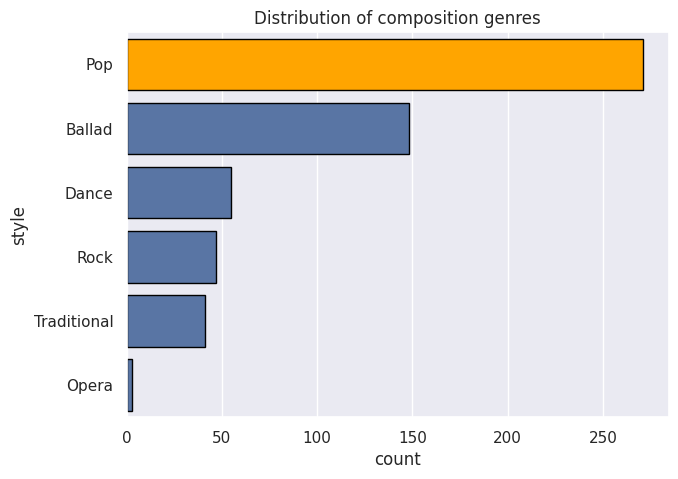

In [8]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(df, y="style", order=df["style"].value_counts().index, edgecolor="black")
ax.patches[0].set_facecolor("orange")
ax.set_title("Distribution of composition genres")

In [9]:
alt.Chart(df, title="Distribution of composition genres").mark_bar(
    stroke="black",
    strokeWidth=1,
).encode(
    x=alt.X("count(style)").title("count"),
    y=alt.Y("style", sort="-x"),
    color=alt.condition(
        alt.datum.style == df["style"].value_counts().index[0],
        alt.value("orange"),
        alt.value('#1f77b4')
    )
).properties(
    width=600,
    height=400,
)

alt.Chart(...)

Видно, что распределение жанров композиций на Евровидении в целом похоже на распределение популярности жанров музыки в принципе: поп-музыка является одним из наиболее популярных жанров не только на Евровидении, но и в мире; а оперу в целом слушают реже, чем, например, рок, и на диаграмме подобная связь имеется

Большое число композиций (2 место по количеству) принадлежит жанру баллады, который, можно сказать, совершенно не на слуху. Возможно, под названием баллады составитель датасета объединил ряд жанров, косвенно подходящих под определение баллады (ориентированная на текст лиро-эпическая форма, часто с повествованием како-либо истории). Например, к балладе в датасете относится песня "Мамо" Анастасии Приходько, а, согласно [Википедии](https://ru.wikipedia.org/wiki/%D0%9C%D0%B0%D0%BC%D0%BE), песня относится к жанру этно-поп.

In [10]:
df[df["song_name"] == "Mamo"]

,year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
561,2009,Russia,Anastasiya Prikhodko,Mamo,"Russian, Ukrainian",Ballad,Female,1,D Minor,130.0,94.0,64.0,45.0,4.0,41.0,0.0,26.0,5.0,11.0


## Задание 5

Покажите на круговой диаграмме страны, участники из которых побеждали чаще других, и в каких годах они выигрывали. Диаграмма должна быть одна.

In [73]:
import plotly.express as px

data = df[df["final_place"] <= 3]
countries = data.groupby("country")["final_place"].count().reset_index()
countries = countries[countries["final_place"] > 1]["country"].values
data = data[data["country"].isin(countries)]
data["final_place"] = data["final_place"].astype(int)
data = data.sort_values("year")


fig = px.sunburst(
    data,
    path=["country", "year"],
    title="Distribution of countries by number of victories",
    width=700,
    height=700,
    color_discrete_sequence=px.colors.qualitative.Pastel,
    labels='label+percent entry'
)
fig.update_traces(textinfo="label+percent entry")

fig.update_layout(
    margin=dict(t=50, l=0, r=0, b=0),
    title_x=0.5
)
fig.show()

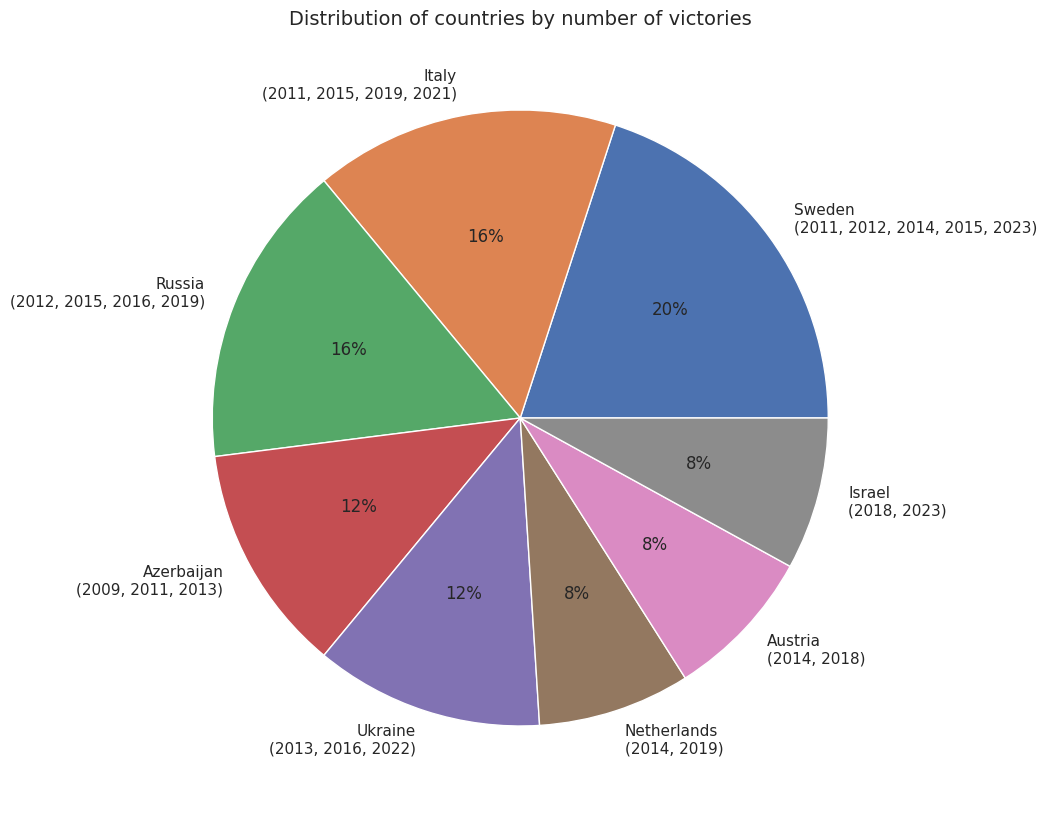

In [12]:
sns.set_theme(style="whitegrid")

data = df[df["final_place"] <= 3]
countries = data.groupby("country")["final_place"].count().reset_index()
countries = countries[countries["final_place"] > 1]["country"].values
data = data[data["country"].isin(countries)]
data["final_place"] = data["final_place"].astype(int)
data = data.sort_values("year")

country_counts = data["country"].value_counts()
country_years = data.groupby("country")["year"].apply(lambda years: ", ".join(map(str, sorted(years))))

labels = [f"{country}\n({country_years[country]})" for country in country_counts.index]
sizes = country_counts.values

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct="%1.0f%%")

plt.title("Distribution of countries by number of victories", fontsize=14)
plt.show()

Видно, что чаще всего победителем (1-3 места) становилась Швеция - 5 раз, затем Россия и Италия - 4 раза, и так далее. Также Швеция - единственная страна, которая подряд занимала призовые места, у остальных стран между получением призовых мест проходит 2-5 лет.

## Задание 6

На вертикальной столбчатой диаграмме с группировкой покажите количество мужчин и женщин среди участников в каждом году, представленном в датасете.

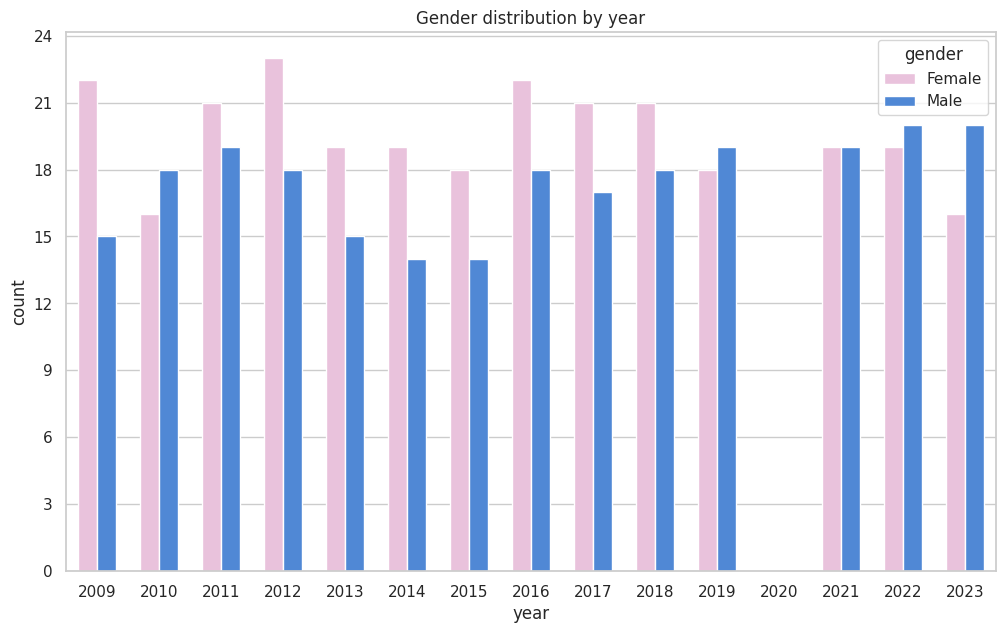

In [13]:
plt.figure(figsize=(12, 7))

all_years = pd.DataFrame({'year': range(df['year'].min(), df['year'].max() + 1)})
distr = df[df["gender"] != "Mix"].groupby(["year", "gender"]).size().reset_index(
    name="count").pivot(index="year", columns="gender", values="count").reset_index()

distr_full = all_years.merge(distr, on='year', how='left').fillna(0).melt(id_vars='year', value_vars=['Female', 'Male'],
                               var_name='gender', value_name='count')

ax = sns.barplot(distr_full, x="year", hue="gender", y="count", palette=["#efbcde", "#3a85eb"], width=0.6)
distr = df.groupby(["year", "gender"]).size().reset_index(name="count").pivot(index="year", columns="gender", values="count")

plt.title("Gender distribution by year")
plt.yticks(range(0, distr["Female"].max() + 3, 3))
plt.show()

In [14]:
bkp.output_notebook()

all_years = pd.DataFrame({'year': range(df['year'].min(), df['year'].max() + 1)})
distr = df[df["gender"] != "Mix"].groupby(["year", "gender"]).size().reset_index(
    name="count").pivot(index="year", columns="gender", values="count").reset_index()

distr_full = all_years.merge(distr, on='year', how='left').fillna(0)
distr_full["year"] = distr_full["year"].astype(str)

fig = bk.plotting.figure(
    x_range=distr_full["year"],
    width=1000
)
fig.title = bk.models.Title(text="Gender distribution by year", align="center", text_font_size="14pt")

fig.vbar(x=bk.transform.dodge("year", 0.11, range=fig.x_range), top="Male", source=distr_full, color="#3a85eb", width=0.2, legend_label="Male")
fig.vbar(x=bk.transform.dodge("year", -0.11, range=fig.x_range), top="Female", source=distr_full, color="#efbcde", width=0.2, legend_label="Female")


bk.plotting.show(fig)

По диаграмме видно, что чаще всего женщин выступало на евровидении больше, чем мужчин. В последние три года мужчин стабильно не меньше, чем женщин; еще в 2010 году было исключение и мужчин было больше.

Диаграммы не учитывают коллективы, поскольку для них не указано, сколько было мужчин, а сколько женщин. Потенциально можно из дуэтов вычленить пол, так как там имена указываются.

## Задание 7

Постройте график плотности распределения данных в столбце `danceability`
(танцевальность), сгруппированных по категориям жанрам.

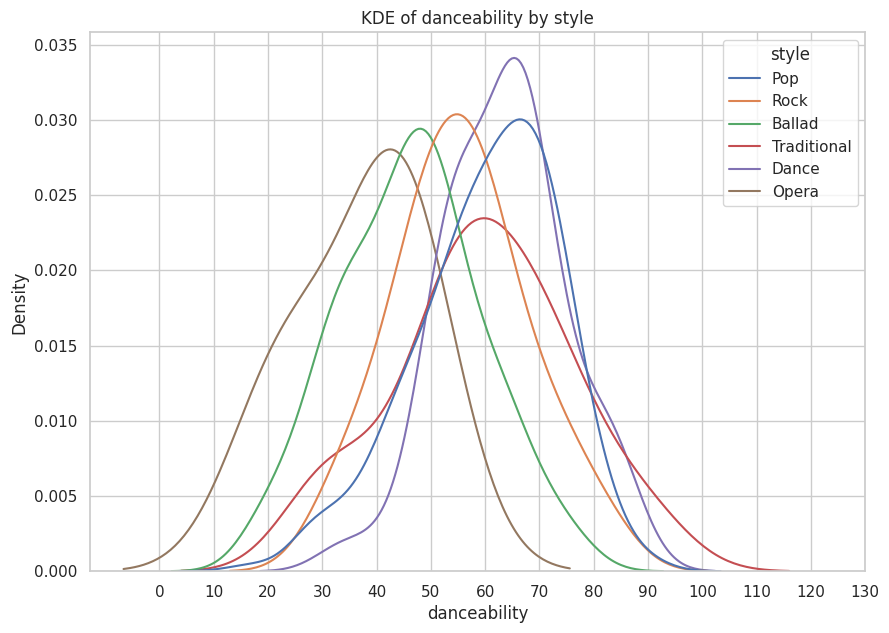

In [15]:
plt.figure(figsize=(10, 7))
sns.kdeplot(df[df["danceability"] != 0], x="danceability", hue="style", fill=False, common_norm=False, alpha=1.0, linewidth=1.5)
plt.title("KDE of danceability by style")
plt.xticks(range(0, int(plt.xticks()[0][-1]), 10))
plt.show()

In [16]:
genres = df["style"].unique()
data_by_genre = [df[(df["style"] == genre) & (df["danceability"] != 0)]["danceability"].values for genre in genres]
labels = list(genres)

fig = create_distplot(
    data_by_genre,
    labels,
    show_hist=False,
    show_rug=False
)

fig.update_layout(
    title="KDE of danceability by style",
    width=800,
    height=600,
    title_x=0.5,
    xaxis_title="danceability",
    yaxis_title="Density"
)
fig.show()

По графикам видно, что у всех распределение у песен всех жанров походит на нормальное, то есть можно сказать, что данные, как минимум, не поддельные. Средние значения танцевальности на графиках плотности отражают логичное соотношение танцевальности жанров: танцевальность у поп-музыки в среднем выше, чем у баллад. Также по графикам можно говорить о разбросе значений танцевальности, например, у поп-музыки разброс возможных значений танцевальности гораздо шире, чем у рок-музыки

## Задание 8

Покажите на ящиковой диаграмме взяимосвязь позиции в финальном рейтинге со страной. Итоги каких стран похожи между собой?

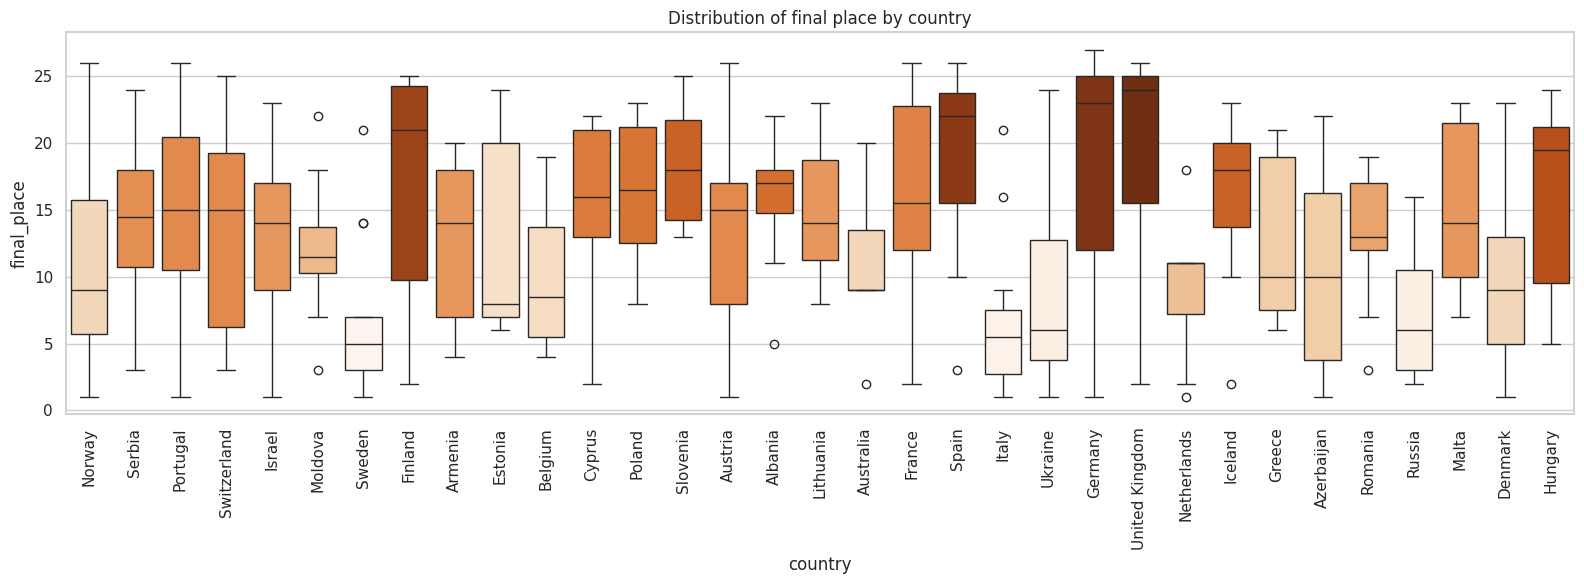

In [17]:
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize, to_hex

df_filtered = df[~df["final_place"].isna()]
df_filtered["final_place"] = df_filtered["final_place"].astype(int)

# оставим только страны, где было 6 илм более участников
top_countries = df_filtered["country"].value_counts()
top_countries = top_countries[top_countries >= 6].index
df_filtered = df_filtered[df_filtered["country"].isin(top_countries)]

medians = df_filtered.groupby("country")["final_place"].median()

# создание цветовой схемы
norm = Normalize(vmin=medians.min(), vmax=medians.max())
cmap = get_cmap("Oranges")
palette = {country: to_hex(cmap(norm(median))) for country, median in medians.items()}

plt.figure(figsize=(16, 6))
sns.boxplot(
    data=df_filtered,
    x="country",
    y="final_place",
    showfliers=True,
    palette=palette
)
plt.title("Distribution of final place by country")
plt.xticks(rotation=90)
plt.ylabel("final_place")
plt.xlabel("country")
plt.tight_layout()
plt.show()


In [18]:
df_filtered = df[~df["final_place"].isna()]
df_filtered = df_filtered.sort_values("final_place")

df_filtered["final_place"] = df_filtered["final_place"].astype(int)

# оставим только страны, где было 6 илм более участников
top_countries = df_filtered["country"].value_counts()
top_countries = top_countries[top_countries >= 6].index
df_filtered = df_filtered[df_filtered["country"].isin(top_countries)]

# Считаем медиану по странам — она будет использоваться для цвета
median_per_country = (
    df_filtered.groupby("country")["final_place"]
    .median()
    .reset_index(name="median_place")
)

# Объединяем медиану с основными данными
data = df_filtered.merge(median_per_country, on="country")

# Строим boxplot
box = alt.Chart(data).mark_boxplot().encode(
    x=alt.X("country:N", sort='y', title="Country"),
    y=alt.Y("final_place:Q", title="Final Place"),
    color=alt.Color("median_place:Q", scale=alt.Scale(scheme="oranges"), legend=None)
).properties(
    width=1000,
    height=600,
    title="Distribution of final place by country"
)

box.configure_axisX(labelAngle=-90).show()


alt.Chart(...)

Между собой похожи: Германия, Финляндия и Великобритания; Румыния и Молдова; Эстония и Греция.

## Задание 9

Покажите на карте количество раз, когда каждая страна датасета проходила в финал.

In [19]:
final_stats = df[~df["final_place"].isna()].groupby("country").size().reset_index(name="count")


fig = px.choropleth(
    final_stats,
    locations="country",
    locationmode="country names",
    color="count",
    color_continuous_scale="Oranges",
    title="Number of finalists by country",
    scope="world",
)

fig.update_geos(
    projection_type="mercator",
    showland=True,
    landcolor="LightGray",
    fitbounds="locations",
    visible=False,
)

fig.update_layout(
    title_x=0.5,
    width=800,
    height=600,
    margin={"r":0,"t": 50,"l":0,"b": 50},
)
fig.show()

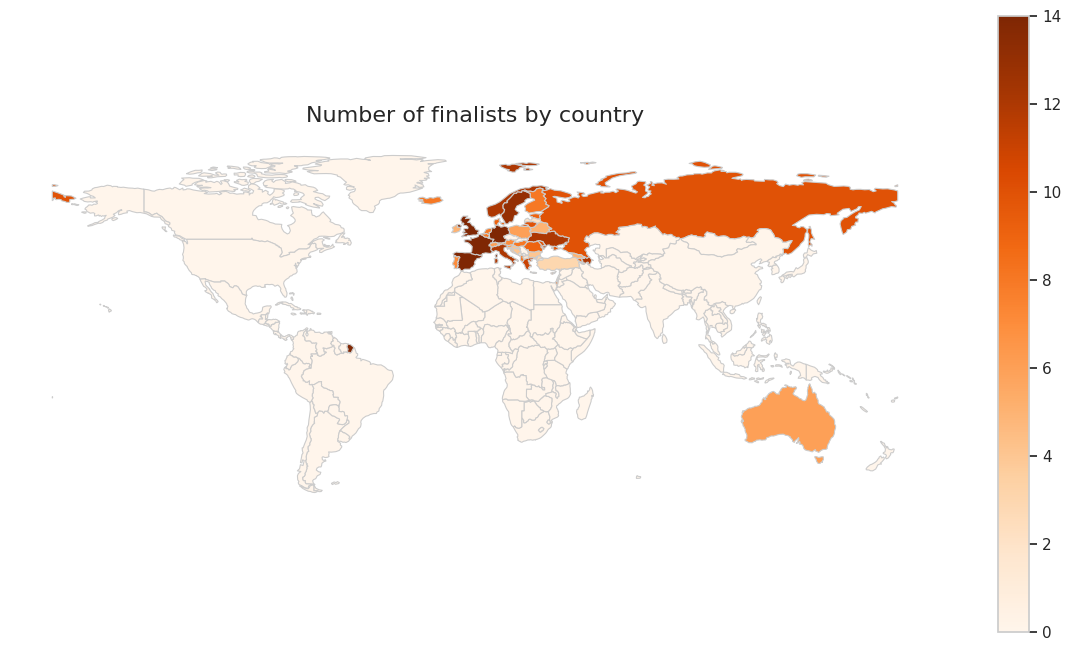

In [74]:
import geopandas as gpd


world = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/files/countries/ne_110m_admin_0_countries.shp")
world = world[~world["ADMIN"].isin(["Antarctica"])]
final_stats = df[~df["final_place"].isna()].groupby("country").size().reset_index(name="count")
merged = world.merge(final_stats, how="left", left_on="ADMIN", right_on="country")
merged["count"] = merged["count"].fillna(0)

fig, ax = plt.subplots(figsize=(15, 8))
merged.plot(
    column="count",
    cmap="Oranges",
    linewidth=0.8,
    ax=ax,
    edgecolor="0.8",
    legend=True
)

ax.set_title("Number of finalists by country", fontdict={'fontsize': 16}, pad=12)
ax.axis('off')

plt.show()


По карте видно, что чаще всег в финал выходили страны Западной Европы: Великобритания, Испания, Франция, Германия. Также в ЕВРОвидении участвуют не только страны Европы, есть, как минимум, Австралия. При этом участвуют не все страны Европы (нет Словакии, Люксембурга и Косово)

## Задание 10

Покажите на диаграмме вида `treemap`, сколько раз каждая страна входила в топ-3 победителей.

*В `seaborn` нет такого типа графика, с помощью этого модуля строить график не нужно.*

In [21]:
top3 = df[df["final_place"].isin([1, 2, 3])]
top3_counts = top3["country"].value_counts().reset_index()
top3_counts.columns = ["country", "top3_count"]

fig = px.treemap(
    top3_counts,
    path=["country"],
    values="top3_count",
    title="Number of countries in the top 3",
    color="top3_count",
    color_continuous_scale="Blues"
)
fig.update_coloraxes(
    colorbar=dict(
        tickmode="linear",
        tick0=0,
        dtick=1
    )
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25), title_x=0.5)
fig.show()


In [32]:
import squarify
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool, LinearColorMapper, ColorBar
from bokeh.palettes import Blues256
from bokeh.io import output_notebook

output_notebook()

data = df[df["final_place"].isin([1, 2, 3])]["country"].value_counts().reset_index()
data.columns = ["country", "count"]

rects = squarify.normalize_sizes(data["count"], 100, 100)
rects = squarify.squarify(rects, 0, 0, 100, 100)

x = [ [r['x'], r['x'] + r['dx'], r['x'] + r['dx'], r['x']] for r in rects ]
y = [ [r['y'], r['y'], r['y'] + r['dy'], r['y'] + r['dy']] for r in rects ]
x_center = [r['x'] + r['dx']/2 for r in rects]
y_center = [r['y'] + r['dy']/2 for r in rects]

color_mapper = LinearColorMapper(palette=Blues256, low=min(data["count"]), high=max(data["count"]))
colors = [Blues256[255 - int((c - min(data["count"])) / (max(data["count"]) - min(data["count"])) * 255)] for c in data["count"]]

source = ColumnDataSource(data=dict(
    x=x,
    y=y,
    x_center=x_center,
    y_center=y_center,
    country=data["country"],
    count=data["count"],
    color=colors
))

p = figure(match_aspect=True, tools="", toolbar_location=None)
p.patches('x', 'y', source=source, fill_color='color', line_color="white", fill_alpha=0.9)

for i in range(len(data)):
    p.text(x_center[i], y_center[i], text=[data["country"][i]], text_align="center", text_baseline="middle", text_font_size="9pt")


p.title = bk.models.Title(text="Number of countries in the top 3", align="center", text_font_size="14pt")

hover = HoverTool(tooltips=[("Страна", "@country"), ("Топ-3 попаданий", "@count")])
p.add_tools(hover)

color_bar = ColorBar(color_mapper=color_mapper, label_standoff=12, location=(0, 0))
p.add_layout(color_bar, 'right')

show(p)


По диаграмме видно, что попадавших в топ-3 стран достаточно много (25 стран), однако попавших в топ-3 2 раза и более всего 8. Из них больше всего брала призовые места Швеция - 5 раз, затем Россия и Италия - 4 раза, после них Азербайджан и Украина - 3 раза, и наконец Австрия, Израиль и Нидерланды - по 2 раза.

## Задание с защиты

In [72]:
import geopandas as gpd
import folium

world = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/files/countries/ne_110m_admin_0_countries.shp")

never_top3 = set(df["country"].unique()) - set(df[df["final_place"].isin([1,2,3])]["country"].unique())
never_top3_df = world[world['ADMIN'].isin(never_top3)]

map_ = folium.Map(
    location=[54, 15],
    zoom_start=4,
    min_zoom=2,
    max_bounds=True,
    tiles="CartoDB positron",
    attr='Countries that never were in top-3 on Eurovision'
)

for _, row in never_top3_df.iterrows():
    folium.Marker(
      location=[row['geometry'].centroid.y, row['geometry'].centroid.x],
      popup=f"{row['ADMIN']} was never in top-3 on Eurovision",
      icon=folium.Icon(color='gray')
    ).add_to(map_)

map_

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения 10 заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой построение визуализации по данным из лабораторной работы, по сложности аналогичной тем, что требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. Покажите на ящиковой диаграмме распределение танцевальности для каждого жанра. Выполните с помощью `seaborn`.
2. На круговой диаграмме покажите исполнителей, которые участвовали больше одного раза и какие места они занимали. Выполните с помощью `plotly`.
3. Покажите на диаграмме вида `treemap`, сколько раз каждая страна проходила в финал. Выполните с помощью `plotly`.

# Дополнительные материалы

1. seaborn: statistical data visualization [Электронный ресурс]. URL: https://seaborn.pydata.org/ (дата обращения: 01.04.2024).
2. Plotly Open Source Graphing Libraries [Электронный ресурс]. URL: https://plotly.com/graphing-libraries/ (дата обращения: 01.04.2024).
3. Vega-Altair: Declarative Visualization in Python [Электронный ресурс]. URL: https://altair-viz.github.io/index.html (дата обращения: 01.04.2024).